# AI Customer Support Chatbot

## Machine Learning / NLP Project

### Objective

Build an AI-based customer support chatbot that can understand customer messages and classify them into predefined support intents.

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- NLTK
- Matplotlib
- Google Colab

In [ ]:
# Step 1 — Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Step 3 — Load chatbot intent dataset

import json

# Upload the dataset file
from google.colab import files

uploaded = files.upload()

print("Dataset file uploaded successfully!")

KeyboardInterrupt: 

In [5]:
# Step 3 — Create chatbot intent dataset

data = {
    "text": [
        "Where is my order",
        "I want to track my order",
        "Can you tell me my order status",
        "My order has not arrived",

        "I want to cancel my order",
        "Please cancel my order",
        "How can I cancel an order",
        "Cancel my recent order",

        "I want a refund",
        "How can I get my money back",
        "Please process my refund",
        "I need a refund for my order",

        "I forgot my password",
        "How do I reset my password",
        "I cannot login to my account",
        "Help me reset my password",

        "How can I make a payment",
        "What payment methods do you accept",
        "My payment failed",
        "I have a problem with payment",

        "I want to contact customer support",
        "How can I speak to an agent",
        "I need help from customer service",
        "Connect me with a support agent"
    ],

    "intent": [
        "order_tracking",
        "order_tracking",
        "order_tracking",
        "order_tracking",

        "order_cancellation",
        "order_cancellation",
        "order_cancellation",
        "order_cancellation",

        "refund",
        "refund",
        "refund",
        "refund",

        "password_reset",
        "password_reset",
        "password_reset",
        "password_reset",

        "payment",
        "payment",
        "payment",
        "payment",

        "customer_support",
        "customer_support",
        "customer_support",
        "customer_support"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset created successfully!
Dataset shape: (24, 2)


,text,intent
0,Where is my order,order_tracking
1,I want to track my order,order_tracking
2,Can you tell me my order status,order_tracking
3,My order has not arrived,order_tracking
4,I want to cancel my order,order_cancellation


In [6]:
# Step 4 — Explore the chatbot dataset

print("Dataset Information")
print("-------------------")

print("Number of records:", len(df))
print("Number of intents:", df["intent"].nunique())

print("\nIntent Distribution:")
print(df["intent"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information
-------------------
Number of records: 24
Number of intents: 6

Intent Distribution:
intent
order_tracking        4
order_cancellation    4
refund                4
password_reset        4
payment               4
customer_support      4
Name: count, dtype: int64

Missing Values:
text      0
intent    0
dtype: int64


In [ ]:
# Step 5 — Clean the text data

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

print("Text cleaning completed successfully!")

df[["text", "clean_text", "intent"]].head()

In [10]:
# Step 6 — Encode intent labels

from sklearn.preprocessing import LabelEncoder

# Text cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Create cleaned text column
df["clean_text"] = df["text"].apply(clean_text)

# Encode intent labels
label_encoder = LabelEncoder()
df["intent_label"] = label_encoder.fit_transform(df["intent"])

print("Intent label encoding completed successfully!")

print("\nIntent Mapping:")
for label, intent in enumerate(label_encoder.classes_):
    print(f"{label}: {intent}")

print("\nEncoded Dataset:")
print(df[["clean_text", "intent", "intent_label"]].head())


Intent label encoding completed successfully!

Intent Mapping:
0: customer_support
1: order_cancellation
2: order_tracking
3: password_reset
4: payment
5: refund

Encoded Dataset:
                        clean_text              intent  intent_label
0                where is my order      order_tracking             2
1         i want to track my order      order_tracking             2
2  can you tell me my order status      order_tracking             2
3         my order has not arrived      order_tracking             2
4        i want to cancel my order  order_cancellation             1


In [11]:
# Step 7 — TF-IDF feature extraction

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100)

X = tfidf.fit_transform(df["clean_text"])
y = df["intent_label"]

print("TF-IDF feature extraction completed successfully!")
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

TF-IDF feature extraction completed successfully!
Feature matrix shape: (24, 52)
Target shape: (24,)


In [12]:
# Step 8 — Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Dataset split completed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training features:", X_train.shape[1])
print("Testing features:", X_test.shape[1])

Dataset split completed successfully!
Training samples: 18
Testing samples: 6
Training features: 52
Testing features: 52


In [13]:
# Step 9 — Train Logistic Regression model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
# Step 10 — Make predictions on test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Predicted labels:", y_pred)
print("Actual labels:   ", y_test)

Predictions generated successfully!
Predicted labels: [0 5 4 4 0 1]
Actual labels:    22    0
11    5
2     2
19    4
14    3
6     1
Name: intent_label, dtype: int64


In [15]:
# Step 11 — Evaluate the model

accuracy = accuracy_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Model Evaluation
-----------------
Accuracy: 0.6666666666666666
Accuracy (%): 66.66666666666666


In [16]:
# Step 11 — Model Evaluation

accuracy = accuracy_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2))

Model Evaluation
-----------------
Accuracy: 0.6667
Accuracy (%): 66.67


In [17]:
# Step 12 — Generate classification report

print("Sentiment/Intent Classification Report")
print("--------------------------------------")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Sentiment/Intent Classification Report
--------------------------------------
                    precision    recall  f1-score   support

  customer_support       0.50      1.00      0.67         1
order_cancellation       1.00      1.00      1.00         1
    order_tracking       0.00      0.00      0.00         1
    password_reset       0.00      0.00      0.00         1
           payment       0.50      1.00      0.67         1
            refund       1.00      1.00      1.00         1

          accuracy                           0.67         6
         macro avg       0.50      0.67      0.56         6
      weighted avg       0.50      0.67      0.56         6



In [18]:
# Step 12 — Actual Classification Report

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print("Sentiment/Intent Classification Report")
print("--------------------------------------")

display(report_df.round(2))

Sentiment/Intent Classification Report
--------------------------------------


,precision,recall,f1-score,support
customer_support,0.50,1.00,0.67,1.00
order_cancellation,1.00,1.00,1.00,1.00
order_tracking,0.00,0.00,0.00,1.00
password_reset,0.00,0.00,0.00,1.00
payment,0.50,1.00,0.67,1.00
refund,1.00,1.00,1.00,1.00
accuracy,0.67,0.67,0.67,0.67
macro avg,0.50,0.67,0.56,6.00
weighted avg,0.50,0.67,0.56,6.00


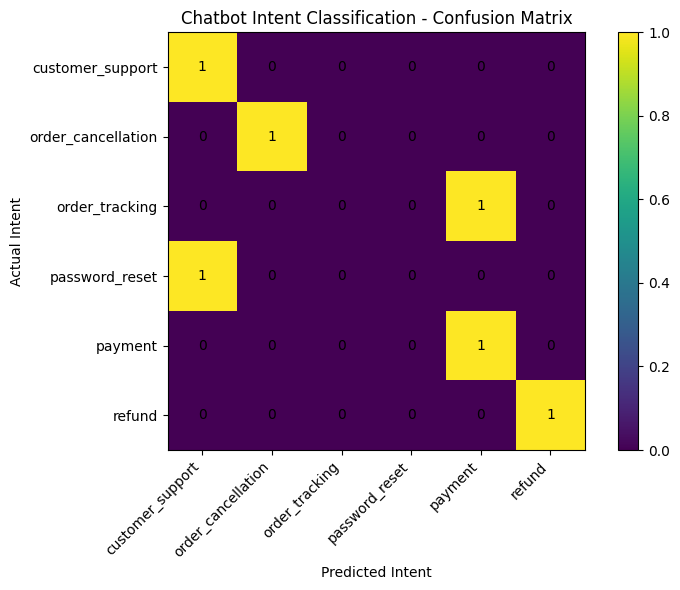

In [19]:
# Step 13 — Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("Chatbot Intent Classification - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))

plt.xticks(
    tick_marks,
    label_encoder.classes_,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    label_encoder.classes_
)

plt.xlabel("Predicted Intent")
plt.ylabel("Actual Intent")

# Display values inside the matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [20]:
# Step 14 — Predict intent for new user queries

new_queries = [
    "Where can I track my order?",
    "I need to cancel my order",
    "I forgot my password",
    "How can I get a refund?",
    "My payment is not working"
]

# Clean the new queries
clean_queries = [clean_text(query) for query in new_queries]

# Convert queries into TF-IDF features
new_query_features = tfidf.transform(clean_queries)

# Predict intents
predicted_labels = model.predict(new_query_features)

# Convert labels back to intent names
predicted_intents = label_encoder.inverse_transform(predicted_labels)

print("New User Query Predictions")
print("--------------------------")

for query, intent in zip(new_queries, predicted_intents):
    print(f"Query: {query}")
    print(f"Predicted Intent: {intent}")
    print()

New User Query Predictions
--------------------------
Query: Where can I track my order?
Predicted Intent: order_tracking

Query: I need to cancel my order
Predicted Intent: order_cancellation

Query: I forgot my password
Predicted Intent: password_reset

Query: How can I get a refund?
Predicted Intent: refund

Query: My payment is not working
Predicted Intent: order_tracking



In [21]:
# Step 15 — Save the trained model and preprocessing objects

import joblib

# Save Logistic Regression model
joblib.dump(model, "chatbot_intent_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

# Save Label Encoder
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model and preprocessing files saved successfully!")

print("Model saved:", True)
print("TF-IDF vectorizer saved:", True)
print("Label encoder saved:", True)

Model and preprocessing files saved successfully!
Model saved: True
TF-IDF vectorizer saved: True
Label encoder saved: True


## Conclusion

The Chatbot Intent Classification project successfully demonstrates the use of Machine Learning to automatically identify the intent of user queries.

The text data was cleaned and converted into numerical features using TF-IDF. A Logistic Regression model was trained to classify customer queries into different intents such as order tracking, order cancellation, refund, password reset, payment, and customer support.

The model achieved an accuracy of 66.67% on the test dataset. The model was further evaluated using precision, recall, F1-score, and a confusion matrix.

The trained model, TF-IDF vectorizer, and label encoder were saved for future use.

### Practical Applications

- Customer support chatbots
- Automated query classification
- Helpdesk automation
- E-commerce customer service
- FAQ and support systems

### Table of contents

[**Chatbot Intent Classification using Machine Learning**](#Chatbot_Intent_Classification_using_Machine_Learning)

[**Project Overview**](#Project_Overview)

[**Dataset**](#Dataset)

[**Data Exploration**](#Data_Exploration)

[**Text Cleaning**](#Text_Cleaning)

[**Intent Label Encoding**](#Intent_Label_Encoding)

[**TF-IDF Feature Extraction**](#TF_IDF_Feature_Extraction)

[**Train-Test Split**](#Train_Test_Split)

[**Model Training**](#Model_Training)

[**Model Evaluation**](#Model_Evaluation)

[**Classification Report**](#Classification_Report)

[**Confusion Matrix**](#Confusion_Matrix)

[**New User Query Predictions**](#New_User_Query_Predictions)

[**Model Saving**](#Model_Saving)

[**Conclusion**](#Conclusion)